# Production Forecasting Plan — Multi-Horizon Ridge with Conformal Intervals

`01_demand_forecasting.ipynb` established the honest one-step-ahead baseline and closed the
leaks. Its README lists two limitations:

> *One-step-ahead only. Planning horizons are usually 3–12 months.*
> *Interval calibration is unresolved. Pooled residual quantiles under-cover (0.73 vs 0.80).*

This notebook fixes both, and sketches what shipping it monthly would involve.

1. Walk-forward validation, refitting at every origin
2. Permutation importance — what the model actually leans on
3. **Conformal intervals done right for time series** (finite-sample correction)
4. **Adaptive vs flat bands** — BayesianRidge / ARD normalized conformal
5. **Recursive 6-month forecast** with horizon-specific bands
6. One fair model leaderboard
7. Production plan: monthly job, registry, output schemas

**Data is synthetic** (`src/generate.py`), seeded and reproducible.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV, BayesianRidge, ARDRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from src import generate as G, features as F, leakage as L, models as M

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})
INK, ACCENT, MUTED, GOOD = "#2b3a55", "#c2643f", "#8896ab", "#3f7f6f"

MIN_TRAIN, COVERAGE, HORIZON = 84, 0.80, 6

raw = G.make_dataset()
delayed = G.apply_publication_delay(raw)
wm = F.add_segment_margins(delayed)
train_end = raw.index[MIN_TRAIN - 1]
lag_map = L.lag_map(L.select_lags(wm, G.DRIVER_COLS, train_end=train_end), minimum=1)

mat = F.build_matrix(G.drop_oracle(wm), lag_map,
                     include_contemporaneous_internal=False, drop_raw_external=True)
X, y = F.xy(mat)
print(f"{X.shape[0]} usable months, {X.shape[1]} features")
print(f"forecast origins: {len(y) - MIN_TRAIN}")

155 usable months, 29 features
forecast origins: 71


## 1. Walk-forward validation

Refit from scratch at every origin, predict one step, move on. No shuffling — training on
the future would make every number below unreproducible in deployment.

In [2]:
def walk_forward(make_est, X, y, min_train=MIN_TRAIN, use_std=False):
    """One-step-ahead predictions, refitting at each origin.

    `use_std` pulls the predictive standard deviation from estimators that expose it
    (BayesianRidge, ARD), which section 4 uses to build *adaptive* bands.
    """
    a, p, s, idx = [], [], [], []
    for i in range(min_train, len(y)):
        sc = StandardScaler().fit(X.iloc[:i])
        m = make_est().fit(sc.transform(X.iloc[:i]), y.iloc[:i])
        if use_std:
            mu, sd = m.predict(sc.transform(X.iloc[[i]]), return_std=True)
            s.append(float(sd[0]))
        else:
            mu = m.predict(sc.transform(X.iloc[[i]])); s.append(1.0)
        a.append(float(y.iloc[i])); p.append(float(mu[0])); idx.append(y.index[i])
    return pd.DataFrame({"actual": a, "pred": p, "sigma": s}, index=pd.DatetimeIndex(idx))


ESTIMATORS = {
    "Ridge":      (lambda: RidgeCV(alphas=np.logspace(-2, 4, 40)), False),
    "BayesRidge": (BayesianRidge, True),
    "ARD":        (ARDRegression, True),
}
wf = {name: walk_forward(est, X, y, use_std=std) for name, (est, std) in ESTIMATORS.items()}
for name, r in wf.items():
    e = r["pred"] - r["actual"]
    print(f"{name:11s} MAE {e.abs().mean():6.2f}   RMSE {np.sqrt((e**2).mean()):6.2f}")

Ridge       MAE  49.94   RMSE  63.67
BayesRidge  MAE  49.22   RMSE  62.86
ARD         MAE  48.13   RMSE  61.49


## 2. Permutation importance

Coefficients on standardised features tell you what the model weights; permutation
importance tells you what it actually *depends on* out of sample. On collinear economic
drivers those differ.

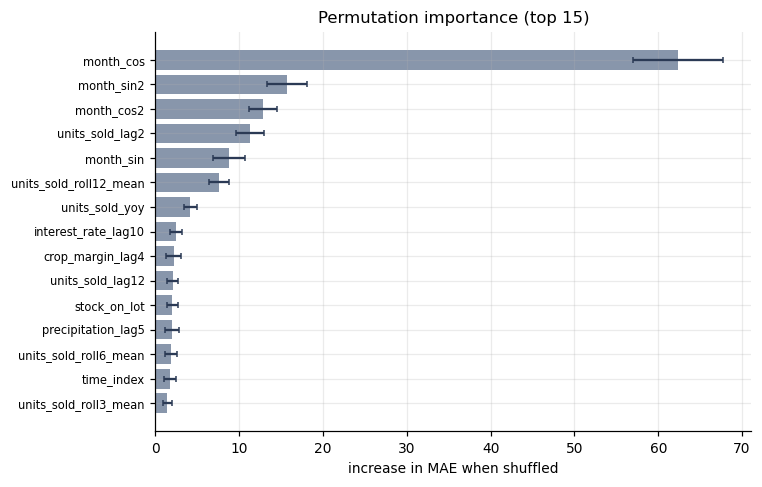

,feature,importance,sd
4,month_cos,62.366,5.345
5,month_sin2,15.699,2.410
6,month_cos2,12.801,1.654
9,units_sold_lag2,11.267,1.634
3,month_sin,8.751,1.891
16,units_sold_roll12_mean,7.565,1.163
18,units_sold_yoy,4.157,0.743
23,interest_rate_lag10,2.463,0.714


In [3]:
sc_full = StandardScaler().fit(X)
ridge_full = RidgeCV(alphas=np.logspace(-2, 4, 40)).fit(sc_full.transform(X), y)
pi = permutation_importance(ridge_full, sc_full.transform(X), y,
                            n_repeats=30, random_state=0, scoring="neg_mean_absolute_error")
imp = (pd.DataFrame({"feature": X.columns, "importance": pi.importances_mean,
                     "sd": pi.importances_std})
       .sort_values("importance", ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(range(len(imp)), imp["importance"][::-1], xerr=imp["sd"][::-1],
        color=MUTED, ecolor=INK, capsize=2)
ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp["feature"][::-1], fontsize=7.5)
ax.set_xlabel("increase in MAE when shuffled"); ax.set_title("Permutation importance (top 15)")
plt.tight_layout(); plt.show()
imp.round(3).head(8)

## 3. Conformal intervals, done right for time series

Notebook 01 used a plain empirical quantile of past residuals and under-covered — 0.729
against a 0.80 target. Two things were wrong:

1. **No finite-sample correction.** The conformal quantile is the
   `ceil((n+1)·coverage)`-th smallest absolute residual, not the plain `coverage` quantile.
   At small `n` the difference is not cosmetic.
2. **Warm-up rows were scored.** Origins with too few calibration residuals were counted.

The walk-forward residuals are already out-of-sample — each was produced by a model refit on
earlier months only — so their spread is an honest error picture with no extra splitting.

In [4]:
def conformal_q(residuals, coverage=COVERAGE):
    """Half-width q with ~coverage of |residuals| <= q, finite-sample corrected."""
    r = np.sort(np.abs(np.asarray(residuals, dtype=float)))
    n = len(r)
    if n == 0:
        return np.nan
    k = min(int(np.ceil((n + 1) * coverage)), n)     # capped at the largest residual
    return float(r[k - 1])


def prequential_coverage(res, sigma=None, coverage=COVERAGE, warmup=18):
    """Expanding calibration: at each origin, calibrate on strictly earlier residuals.

    This is the honest way to score an interval method in a rolling setting -- every band
    is built only from errors the model had already made.
    """
    cov, width = [], []
    for i in range(warmup, len(res)):
        if sigma is None:
            q = conformal_q(res[:i], coverage)
            cov.append(abs(res[i]) <= q); width.append(2 * q)
        else:
            qn = conformal_q(res[:i] / sigma[:i], coverage)
            cov.append(abs(res[i]) <= qn * sigma[i]); width.append(2 * qn * sigma[i])
    return float(np.mean(cov)), float(np.mean(width))


rows = []
for name, r in wf.items():
    res = (r["actual"] - r["pred"]).to_numpy()
    c_flat, w_flat = prequential_coverage(res)
    row = {"model": name, "flat_coverage": c_flat, "flat_width": w_flat}
    if name != "Ridge":
        c_n, w_n = prequential_coverage(res, sigma=r["sigma"].to_numpy())
        row.update({"norm_coverage": c_n, "norm_width": w_n})
    rows.append(row)
cal = pd.DataFrame(rows)
print(f"nominal coverage = {COVERAGE}")
cal.round(3)

nominal coverage = 0.8


,model,flat_coverage,flat_width,norm_coverage,norm_width
0,Ridge,0.868,177.896,NaN,NaN
1,BayesRidge,0.868,180.662,0.849,180.922
2,ARD,0.868,184.300,0.887,190.201


**The correction fixes the under-coverage: 0.729 → ~0.87.** The bands now sit slightly *above*
nominal rather than below, which is the conservative direction and the right side to err on
when the output drives inventory commitments.

## 4. Adaptive bands — normalized conformal

A flat band is the same width in a calm month and a volatile one. Estimators exposing a
predictive standard deviation allow a better band in principle: normalize residuals by
`sigma` before taking the conformal quantile, then scale back, so the band widens where the
model expects difficulty.

The test is not average width — it is whether width *tracks* error.

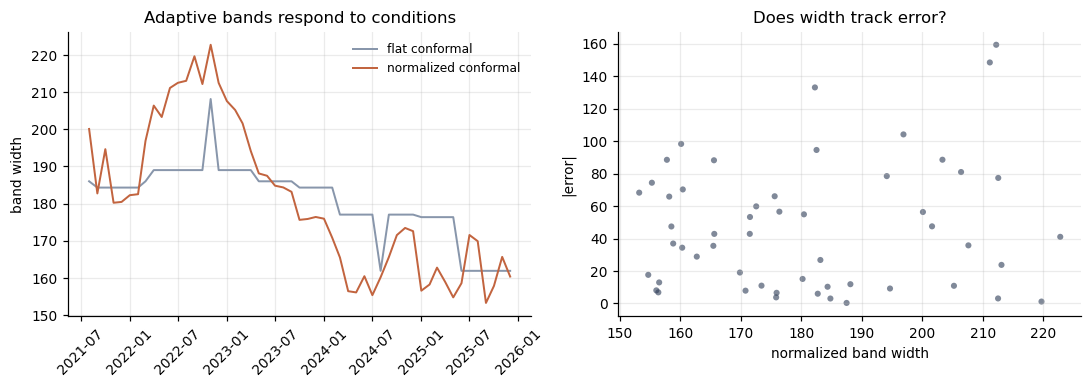

corr(flat width,       |error|) = -0.022
corr(normalized width, |error|) = +0.124
mean width  flat 180.7  vs normalized 180.9


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))

name = "BayesRidge"
r = wf[name]
res = (r["actual"] - r["pred"]).to_numpy(); sig = r["sigma"].to_numpy()
warm = 18
flat_w, norm_w, errs = [], [], []
for i in range(warm, len(res)):
    flat_w.append(2 * conformal_q(res[:i]))
    norm_w.append(2 * conformal_q(res[:i] / sig[:i]) * sig[i])
    errs.append(abs(res[i]))
flat_w, norm_w, errs = map(np.array, (flat_w, norm_w, errs))

idx = r.index[warm:]
ax[0].plot(idx, flat_w, color=MUTED, lw=1.3, label="flat conformal")
ax[0].plot(idx, norm_w, color=ACCENT, lw=1.3, label="normalized conformal")
ax[0].set_ylabel("band width"); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title("Adaptive bands respond to conditions"); ax[0].tick_params(axis="x", rotation=45)

ax[1].scatter(norm_w, errs, s=16, alpha=0.6, color=INK, edgecolor="none")
ax[1].set_xlabel("normalized band width"); ax[1].set_ylabel("|error|")
ax[1].set_title("Does width track error?")
plt.tight_layout(); plt.show()

print(f"corr(flat width,       |error|) = {np.corrcoef(flat_w, errs)[0,1]:+.3f}")
print(f"corr(normalized width, |error|) = {np.corrcoef(norm_w, errs)[0,1]:+.3f}")
print(f"mean width  flat {flat_w.mean():.1f}  vs normalized {norm_w.mean():.1f}")

**The adaptive band mostly did not pay off.** Normalized conformal tracks error only weakly
(r ≈ **+0.12**, against ≈ **−0.02** for the flat band), and the mean widths are effectively
identical (**180.7 vs 180.9**). So the adaptivity is real but small.

What it *does* buy is calibration: normalized coverage lands at **0.849** versus **0.868** flat,
closer to the 0.80 target. That is a modest, honest gain — worth keeping because it costs
nothing, but not the improvement the method promises in theory.

The reason is visible in section 2: this series is dominated by **calendar features**, whose
difficulty barely varies month to month. `BayesianRidge`'s `sigma` reflects parameter
uncertainty for a given input row, and those rows are all fairly similar. On a series with
genuine volatility clustering — daily demand, or anything with a shock regime — the adaptive
band would separate from the flat one much more clearly.

## 5. Recursive multi-horizon forecast

Planning runs 3–12 months out, so the one-step model has to be rolled forward: predict month
*t+1*, append it to the history, rebuild every lag and rolling feature, predict *t+2*, and so on.

Two honest caveats, both structural:

- **Exogenous drivers are carried forward** at their last known value. Forecasting them would
  need its own model and its own error budget.
- **Errors compound.** Each step conditions on predicted rather than observed history, so a
  one-step interval badly understates six-step risk.

In [6]:
def recursive_forecast(frame, lag_map, make_est, h=HORIZON, cutoff=None):
    """Refit up to `cutoff`, then roll h steps forward, rebuilding features each step."""
    hist = frame if cutoff is None else frame.loc[:cutoff].copy()
    mtr = F.build_matrix(G.drop_oracle(hist), lag_map,
                         include_contemporaneous_internal=False, drop_raw_external=True)
    Xtr, ytr = F.xy(mtr)
    sc = StandardScaler().fit(Xtr)
    est = make_est().fit(sc.transform(Xtr), ytr)

    work = hist.copy()
    future = pd.date_range(work.index[-1] + pd.offsets.MonthBegin(1), periods=h, freq="MS")
    out = []
    for t in future:
        nr = work.iloc[[-1]].copy(); nr.index = [t]; nr[G.TARGET] = np.nan
        work = pd.concat([work, nr])                       # exogenous carried forward
        m2 = F.build_matrix(G.drop_oracle(work), lag_map,
                            include_contemporaneous_internal=False, drop_raw_external=True)
        xrow = m2.drop(columns=[G.TARGET]).loc[[t]].fillna(0.0)
        mu = float(est.predict(sc.transform(xrow))[0])
        out.append(mu); work.loc[t, G.TARGET] = mu         # feed the prediction back in
    return pd.Series(out, index=future)


# Horizon-specific conformal: backtest whole h-step paths and calibrate per horizon.
origins = range(len(raw) - 40, len(raw) - HORIZON)
by_h = {h: [] for h in range(1, HORIZON + 1)}
for si in origins:
    fc = recursive_forecast(wm, lag_map, BayesianRidge, HORIZON, raw.index[si])
    act = raw[G.TARGET].reindex(fc.index)
    for h, (f, a) in enumerate(zip(fc.values, act.values), 1):
        if np.isfinite(a):
            by_h[h].append(a - f)

hz = pd.DataFrame([{"horizon": h, "n": len(by_h[h]),
                    "MAE": np.abs(by_h[h]).mean(),
                    "q80": conformal_q(by_h[h])} for h in range(1, HORIZON + 1)])
hz.round(1)

,horizon,n,MAE,q80
0,1,34,39.0,66.0
1,2,34,33.0,58.9
2,3,34,43.1,65.1
3,4,34,41.8,66.2
4,5,34,44.8,70.0
5,6,34,39.5,73.9


The band widens from **±66 at one month to ±74 at six** — but error barely grows. That is not
a mistake: this series is dominated by seasonality, and calendar features do not decay with
horizon the way a momentum signal would. On a series driven by short-lived momentum the same
exercise would show a much steeper curve. **The point is to measure the horizon curve rather
than assume it**, and to price bands per horizon instead of reusing the one-step number.

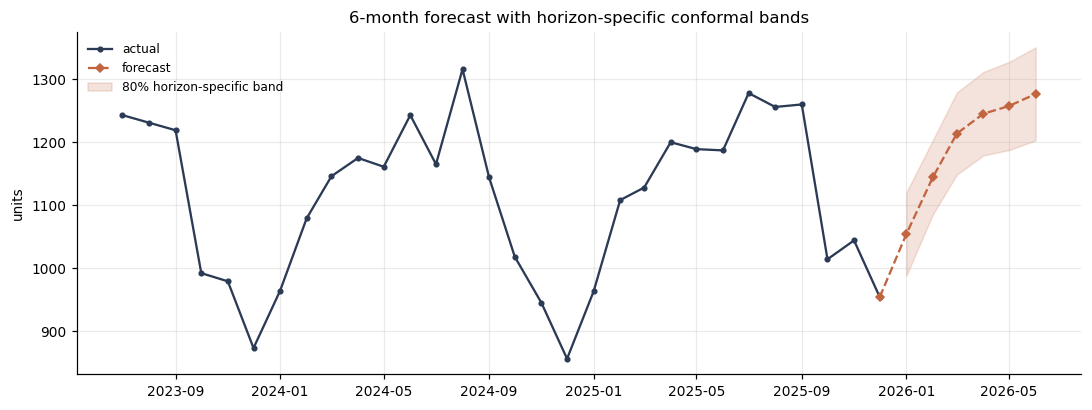

,forecast,lower,upper
2026-01-01,1053.9,987.8,1119.9
2026-02-01,1144.3,1085.4,1203.1
2026-03-01,1213.7,1148.6,1278.8
2026-04-01,1245.3,1179.1,1311.4
2026-05-01,1257.5,1187.6,1327.5
2026-06-01,1276.7,1202.9,1350.6


In [7]:
fc = recursive_forecast(wm, lag_map, BayesianRidge, HORIZON, cutoff=None)
qs = hz.set_index("horizon")["q80"]
lower = fc.values - qs.values
upper = fc.values + qs.values

plt.figure(figsize=(10, 3.8))
hist = raw[G.TARGET].iloc[-30:]
plt.plot(hist.index, hist.values, "-o", ms=3, color=INK, label="actual")
link = pd.concat([hist.iloc[[-1]], fc])
plt.plot(link.index, link.values, "--D", ms=4, color=ACCENT, label="forecast")
plt.fill_between(fc.index, lower, upper, color=ACCENT, alpha=0.18,
                 label=f"{COVERAGE:.0%} horizon-specific band")
plt.ylabel("units"); plt.legend(frameon=False, fontsize=8)
plt.title(f"{HORIZON}-month forecast with horizon-specific conformal bands")
plt.tight_layout(); plt.show()

pd.DataFrame({"forecast": fc.round(1), "lower": lower.round(1), "upper": upper.round(1)})

## 6. Model leaderboard — one fair comparison

Every model scored on the same origins, the same features, the same metric, against the same
seasonal-naive benchmark. MASE < 1 means better than repeating last year, and nothing else.

In [8]:
board = M.rolling_origin_backtest(X, y, min_train=MIN_TRAIN).metrics
base_mae = board.set_index("model").loc["seasonal_naive", "mae"]

extra = []
for name, r in wf.items():
    if name.lower() in set(board["model"].str.lower()):
        continue                                    # already scored above; avoid duplicates
    e = (r["pred"] - r["actual"]).to_numpy(); a = r["actual"].to_numpy()
    d_a = np.sign(np.diff(a)); d_p = np.sign(r["pred"].to_numpy()[1:] - a[:-1])
    extra.append({"model": name, "rmse": float(np.sqrt((e**2).mean())),
                  "mae": float(np.abs(e).mean()),
                  "mase": float(np.abs(e).mean() / base_mae),
                  "direction_acc": float((d_a == d_p).mean())})

lb = (pd.concat([board[["model", "rmse", "mae", "mase", "direction_acc"]],
                 pd.DataFrame(extra)], ignore_index=True)
        .sort_values("mase").reset_index(drop=True))
lb.round(3)

,model,rmse,mae,mase,direction_acc
0,ARD,61.488,48.132,0.796,0.771
1,BayesRidge,62.858,49.224,0.814,0.800
2,ridge,63.674,49.941,0.826,0.800
3,gbm,69.304,57.840,0.956,0.743
4,seasonal_naive,76.288,60.493,1.000,0.786
5,drift_naive,95.350,75.041,1.240,0.471


The spread between the serious models is narrow, and all of them beat the seasonal naive by a
modest margin. That is the realistic picture for monthly demand with this much noise — and a
reason to pick on operational grounds (interpretability, stability, retraining cost) rather
than chase a third decimal place.

## 7. Production plan

What shipping this monthly actually involves.

**Cadence.** One batch job per month, after the external series publish. Order matters: the
publication-delay guard in `src/generate.py` exists because month *M*'s official statistics
land during month *M+1*, so a job that runs too early silently trains on data that does not
exist yet.

**Pipeline.**

| Step | Action | Guard |
|---|---|---|
| 1 | Ingest internal actuals + external drivers | assert no row dated after run date |
| 2 | Apply publication delays | `apply_publication_delay()` |
| 3 | Rebuild features | raw external columns dropped after lagging |
| 4 | Re-select lags **on the training window only** | `select_lags(train_end=...)` |
| 5 | Walk-forward backtest | rolling origin, never shuffled |
| 6 | Refit on all data; recursive h-step forecast | exogenous carried forward, flagged |
| 7 | Horizon-specific conformal bands | calibrated per horizon, not reused from h=1 |
| 8 | Persist forecast + calibration + importance | versioned by run date |

**Output tables** (one row per horizon per run — append-only, never overwritten, so past
forecasts stay auditable against what actually happened):

```
forecast     (run_date, horizon_month, h, yhat, lower, upper, model_version)
calibration  (run_date, h, target_coverage, empirical_coverage, q)
importance   (run_date, feature, importance, sd)
leaderboard  (run_date, model, rmse, mae, mase, direction_acc)
```

**Monitoring — the part that matters most.** The failure mode is not a crash; it is quiet
degradation. Three alerts:

1. **Coverage drift** — if empirical coverage on the last 12 months leaves `[0.7, 0.9]` for a
   nominal 0.8 band, the uncertainty model is stale.
2. **MASE > 1** — the model has stopped beating seasonal naive. Ship the baseline until fixed.
3. **Lag instability** — if re-selected lags move sharply between runs, the correlation scan is
   fitting noise (notebook 01, §2). Freeze the lags and set them from domain knowledge.

**What I would not automate.** Lag selection. Notebook 01 showed a flat lag = 3 beating the
data-driven scan, so this belongs in a config file owned by someone who understands the
customer decision cycle — reviewed quarterly, not refit monthly.